# Extracción de datos web

## Índice
1. [Recepción de páginas web con urllib](#urllib)
2. [Parsing de HTML mediante BeatifulSoup](#bea)
3. [Ejemplos de web scraping](#ejemplos)
4. [Web scraping con selenium](#sele)

<a id="urllib"></a>
## Recepción de páginas web con urllib

In [1]:
import urllib.request
f = urllib.request.urlopen('https://www.iebschool.com/')
print(f.read().decode())

<!doctype html>
<html lang="es">
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link rel="shortcut icon" href="/build/static/favicon.ico"/>
    <meta name="title" content="IEBS - La Escuela de Negocios de la Innovación y los Emprendedores" />
<meta name="description" content="IEBS, la Escuela de Negocios de la Innovación y los Emprendedores, ofrece Formación actual de Empresa, Marketing, Internet, RRHH y Finanzas" />
<meta name="keywords" content="escuela de negocios, escuela de emprendedores, business school, ranking, mejores" />
<meta name="language" content="es" />
<meta name="robots" content="index, follow" />
<meta name="google-site-verification" content="er9GGkNg-pFioB47cNe0EJyBBRvKfMLLt5WJk9U-C-Q" />
<meta name="msvalidate.01" content="D98ECBBF938B6CBF34DFF4A44E836885" />
<meta name="yandex-verification" content="3469289df7caad4f" />
    <title>IEBS - La Escuela de Negocios de la Innovación y los 

<a id="bea"></a>
## Parsing de HTML mediante BeatifulSoup

BeautifulSoup es una librería de Python que permite analizar documentos HTML y extraer datos de ellos, compensando imperfecciones que puedan existir. Para instalar esta librería escribimos en anaconda Prompt:  
`conda install -c anaconda beautifulsoup4`

Esta librería permite, por ejemplo, extraer los atributos href de las etiquetas de anclaje (a)  
<img src='http://www.cellbiol.com/bioinformatics_web_development/wp-content/uploads/2017/01/attributes_and_values_in_the_a_tag.png'>  
En el siguiente ejemplo, vamos a parsear una entrada HTML y extraer los links utilizando la librería BeautifulSoup. 
Utilizaremos urllib para leer la página y después BeautifulSoup para extraer los atributos href de las etiquetas de tipo ancla (a)

In [2]:
from bs4 import BeautifulSoup

url = 'https://www.iebschool.com/'
html = urllib.request.urlopen(url)
soup = BeautifulSoup(html)

tags = soup('a')

for tag in tags:
    print(tag.get('href'))

/
#
https://www.iebschool.com/conocenos/
https://www.iebschool.com/por-que-elegirnos/
https://www.iebschool.com/becas-y-ayudas/
https://www.iebschool.com/metodologia/
https://www.iebschool.com/proceso-de-admision/
https://www.iebschool.com/consejo-academico/
https://www.iebschool.com/ranking-y-acreditaciones/
https://www.iebschool.com/conocenos/partners/
https://www.iebschool.com/convenios-academicos/
https://www.iebschool.com/conocenos/comunidad/
https://www.iebschool.com/responsabilidad-social/
#
https://www.iebschool.com/programas/mba-emprendedores/
https://www.iebschool.com/programas/mba/
https://www.iebschool.com/programas/emprendedores/
https://www.iebschool.com/programas/transformacion-digital/
https://www.iebschool.com/programas/marketing-digital/
https://www.iebschool.com/programas/seo-sem/
https://www.iebschool.com/programas/e-commerce/
https://www.iebschool.com/programas/inbound-marketing/
https://www.iebschool.com/programas/growth-hacking/
https://www.iebschool.com/programa

Podemos extraer más campos de las etiquetas

In [3]:
for tag in tags:
    print('URL:', tag.get('href'))
    print('Texto:', tag.text)
    print('\r')

URL: /
Texto: 



URL: #
Texto: SOMOS IEBS

URL: https://www.iebschool.com/conocenos/
Texto: Conócenos

URL: https://www.iebschool.com/por-que-elegirnos/
Texto: Por qué elegirnos

URL: https://www.iebschool.com/becas-y-ayudas/
Texto: Becas y Ayudas

URL: https://www.iebschool.com/metodologia/
Texto: Metodología

URL: https://www.iebschool.com/proceso-de-admision/
Texto: Proceso de admisión

URL: https://www.iebschool.com/consejo-academico/
Texto: Consejo Académico

URL: https://www.iebschool.com/ranking-y-acreditaciones/
Texto: Rankings y Acreditaciones

URL: https://www.iebschool.com/conocenos/partners/
Texto: Partners

URL: https://www.iebschool.com/convenios-academicos/
Texto: Convenios académicos

URL: https://www.iebschool.com/conocenos/comunidad/
Texto: Comunidad Alumni

URL: https://www.iebschool.com/responsabilidad-social/
Texto: Responsabilidad Social

URL: #
Texto: FORMACIÓN

URL: https://www.iebschool.com/programas/mba-emprendedores/
Texto: MBA y Emprendedores

URL: https://

Puedes encontrar la documentación de beautifulsoup en https://www.crummy.com/software/BeautifulSoup/bs4/doc/

<a id="ejemplos"></a>
## Ejemplos de web scraping

### 1. Frecuencia de las palabras de un discurso  
Vamos a obtener la frecuencia de las palabras del siguiente discurso: https://elpais.com/internacional/2018/01/31/actualidad/1517387619_036241.html

In [20]:
import urllib.request
from bs4 import BeautifulSoup

url = 'https://elpais.com/internacional/2018/01/31/actualidad/1517387619_036241.html'
html = urllib.request.urlopen(url)
soup = BeautifulSoup(html)

tags = soup('p')

discurso = ''

for tag in tags:
    if tag.text == 'Traducción de New Clips':
        break
    else:
        discurso += tag.text
    
discurso = discurso.lower()
discurso = discurso.replace(',',' ').replace('.', ' ').replace(':', ' ').replace(')',' ').replace('?',' ')

palabras = discurso.split()

contador = {}

for palabra in palabras:
    if len(palabra)>3 and palabra not in ['esta','para','este','estos']:
        contador[palabra] = contador.get(palabra,0) + 1
    
import pandas as pd
df = pd.DataFrame(list(contador.items()), columns=['palabra','contador'])
df.sort_values('contador', ascending=False)

,palabra,contador
12,estadounidenses,33
543,nuestros,28
29,nuestro,28
55,hemos,27
10,unidos,27
...,...,...
876,oficio,1
875,aprender,1
874,futuros,1
873,profesional,1


### 2. Web Scraping de bitcoin
Extraemos el valor más reciente de Bitcoin en https://www.estrategiasdeinversion.com/cotizaciones/criptomonedas/bitcoin

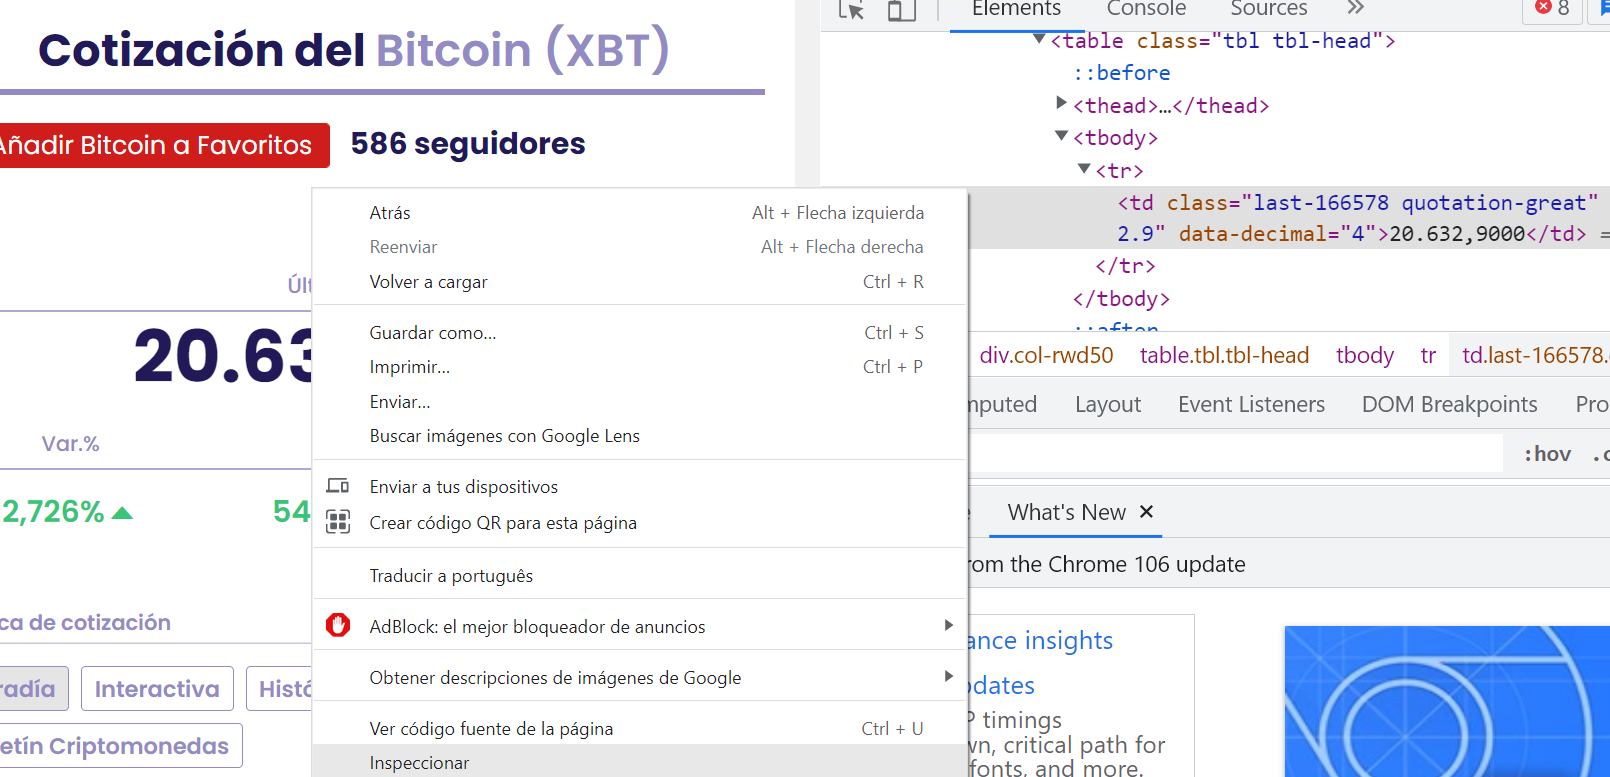

In [21]:
import urllib.request
from bs4 import BeautifulSoup

url = 'https://www.estrategiasdeinversion.com/cotizaciones/criptomonedas/bitcoin'
html = urllib.request.urlopen(url)
soup = BeautifulSoup(html)

tags = soup.find_all('td', class_ = 'last-166578 quotation-great')

bitcoin = float(tags[0].text.replace('.','').replace(',','.'))
bitcoin

118024.2

### 3. Web scraping con pandas 

La función `read_html()` de pandas también permite extraer tablas de páginas web, devolviendo una lista de dataframes con todas las tablas que existan.  
Por ejemplo, vamos a hacer scraping de la siguiente tabla: https://www.fdic.gov/resources/resolutions/bank-failures/failed-bank-list/

Es necesario instalar la librería `lxml`: `conda install -c conda-forge lxml`

In [48]:
!pip install lxml

  Obtaining dependency information for lxml from https://files.pythonhosted.org/packages/31/58/e3b3dd6bb2ab7404f1f4992e2d0e6926ed40cef8ce1b3bbefd95877499e1/lxml-4.9.3-cp311-cp311-win_amd64.whl.metadata
  Using cached lxml-4.9.3-cp311-cp311-win_amd64.whl.metadata (3.9 kB)
Using cached lxml-4.9.3-cp311-cp311-win_amd64.whl (3.8 MB)


In [53]:
import pandas as pd
url = 'https://www.fdic.gov/resources/resolutions/bank-failures/failed-bank-list/'
tablas = pd.read_html(url)
tablas[0]

,Bank NameBank,CityCity,StateSt,CertCert,Acquiring InstitutionAI,Closing DateClosing,FundFund
0,Heartland Tri-State Bank,Elkhart,KS,25851,"Dream First Bank, N.A.","July 28, 2023",10544
1,First Republic Bank,San Francisco,CA,59017,"JPMorgan Chase Bank, N.A.","May 1, 2023",10543
2,Signature Bank,New York,NY,57053,"Flagstar Bank, N.A.","March 12, 2023",10540
3,Silicon Valley Bank,Santa Clara,CA,24735,First–Citizens Bank & Trust Company,"March 10, 2023",10539
4,Almena State Bank,Almena,KS,15426,Equity Bank,"October 23, 2020",10538
...,...,...,...,...,...,...,...
562,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB","July 27, 2001",6004
563,Malta National Bank,Malta,OH,6629,North Valley Bank,"May 3, 2001",4648
564,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,"February 2, 2001",4647
565,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,"December 14, 2000",4646


In [24]:
# Voy a hacer la prueba con polars
import polars as pl

url = 'https://www.fdic.gov/resources/resolutions/bank-failures/failed-bank-list/'

html = urllib.request.urlopen(url)
soup = BeautifulSoup(html)

print(soup)

<!DOCTYPE html>

<html dir="ltr" lang="en" prefix="og: https://ogp.me/ns#">
<head>
<meta charset="utf-8"/>
<meta content="This list includes banks, which have failed since October 1, 2000." name="description"/>
<link href="https://www.fdic.gov/bank-failures/failed-bank-list" rel="canonical"/>
<meta content="website" property="og:type"/>
<meta content="https://www.fdic.gov/bank-failures/failed-bank-list" property="og:url"/>
<meta content="Failed Bank List | FDIC.gov" property="og:title"/>
<meta content="This list includes banks, which have failed since October 1, 2000." property="og:description"/>
<meta content="https://www.fdic.gov/system/files?file=2025-03/fdic-seal.png" property="og:image"/>
<meta content="1200" property="og:image:width"/>
<meta content="600" property="og:image:height"/>
<meta content="Federal Deposit Insurance Corporation seal" property="og:image:alt"/>
<meta content="summary_large_image" name="twitter:card"/>
<meta content="@FDICgov" name="twitter:site"/>
<meta con

### 4. Agente de usuario

El **agente de usuario** es un identificador con el que un programa inicia sesión en el servidor web para solicitar datos

Cuando un usuario accede a una página web, la aplicación generalmente envía una cadena de texto que identifica al agente de usuario ante el servidor. Este texto forma parte de la petición a través de HTTP, llevando como prefijo
*User-Agent*, y generalmente incluye información como el nombre de la aplicación, la versión, el sistema operativo, y el idioma. 

La identificación de agente de usuario es uno de los criterios de exclusión utilizado para impedir el acceso a ciertas secciones de un sitio web.

Ejemplo: Obtenemos la altura de los futbolistas desde la web de transfermarkt:  
https://www.transfermarkt.es/lionel-messi/profil/spieler/28003


In [26]:
import urllib.request
from bs4 import BeautifulSoup
url = 'https://www.transfermarkt.es/lionel-messi/profil/spieler/28003'
req = urllib.request.Request(
    url, 
    data=None, 
    headers={
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/35.0.1916.47 Safari/537.36'
    }
)

html = urllib.request.urlopen(req)
soup = BeautifulSoup(html)
tags = soup.find_all(attrs={'itemprop':'height'})
altura = float(tags[0].text.replace(' m','').replace(',','.').strip())
altura

1.7

<a id="sele"></a>
## Web Scraping con Selenium

Selenium es una librería que permite automatizar navegadores web

Documentación: https://selenium-python.readthedocs.io/

Instalar librerías `selenium` y `webdriver_manager`

In [221]:
from selenium import webdriver
from webdriver_manager.firefox import GeckoDriverManager
from selenium.webdriver.firefox.service import Service as FirefoxService
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
import time

In [222]:
driver = webdriver.Firefox(service=Service(GeckoDriverManager().install()))  # Windows users
# driver = webdriver.Chrome() # Mac users

### Ejemplo 1: Introducir una búsqueda en la web de carrefour y extraer el precio de los productos

In [223]:
# Accedo a la web
driver.get('https://www.carrefour.es')

In [224]:
# Aceptar cookies
time.sleep(1)  # Esperar a que se cargue la página
driver.find_element('xpath', '//*[@id="onetrust-accept-btn-handler"]').click()

In [225]:
# Click en la barra de búsqueda
driver.find_element('xpath','//*[@id="search-input"]').click()

In [226]:
# Enviar texto de búsqueda
# Vamos a ir letra a letra para simular ser humanos

time.sleep(2)  # Esperar a que se cargue la página
query = 'Leche Pascual'

for letra in query:
    driver.find_element('xpath','/html/body/div[4]/div/div/div[1]/div/div[2]/div[1]/div[1]/header/div/div/div/input').send_keys(letra)
    time.sleep(0.2)  # Esperar medio segundo entre cada letra


In [227]:
print(input_element.get_attribute('value'))  # Verificar que se ha escrito correctamente

WebDriverException: Message: Failed to decode response from marionette


In [ ]:
# Extraer el código fuente
html = driver.page_source

In [ ]:
# Extraemos los datos con BeautifulSoup
from bs4 import BeautifulSoup
soap = BeautifulSoup(html)

<html lang="es" style=""><head>
<title>Compra Online en Carrefour: Ofertas en Alimentación, Tecnología, Hogar</title>
<meta content="Compra online en Carrefour y ahorra. Encuentra alimentación fresca, electrodomésticos, tecnología, moda y mucho más. ¡Entrega a domicilio o recogida en tienda!" name="description"/><meta content="compra online carrefour, compra online, carrefour online, carrefour españa, ofertas carrefour, comprar carrefour" name="keywords"/>
<meta charset="utf-8"/>
<meta content="yes" name="mobile-web-app-capable"/>
<meta content="yes" name="apple-mobile-web-app-capable"/>
<meta content="default" name="apple-mobile-web-app-status-bar-style"/>
<meta content="IE=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width, initial-scale=1, minimal-ui" name="viewport"/>
<meta content="#ffffff" name="theme-color"/>
<link href="/dist/rendering/home-front/img/favicon.ico" rel="shortcut icon" sizes="16x16"/>
<link href="/dist/rendering/home-front/manifest.json" rel="m
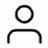
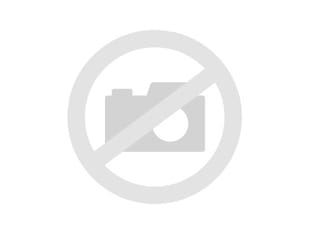
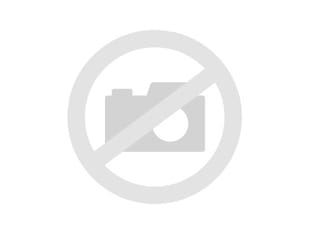
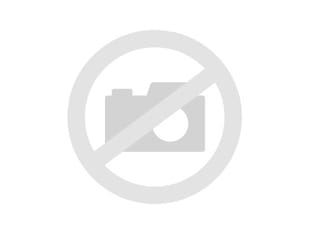
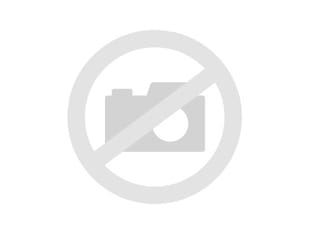
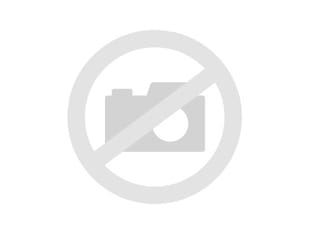

In [ ]:
soap

In [ ]:
# Extraemos los nombres de los productos
productos = soap.find_all('p',class_="x-font-bold x-leading-[1.2] hover:x-underline x-line-clamp-2")

# Recorremos los productos y los añadimos a la lista
lista_productos = []

for prod in productos:
    lista_productos.append(prod.text)
lista_productos

[]

In [ ]:
# Extraemos los precios de los productos
precios = soap.find_all('span',class_='x-currency')

# Recorremos los precios y los añadimos a la lista
lista_precios = []
for precio in precios:
    lista_precios.append(precio.text)

lista_precios

[]

In [ ]:
import pandas as pd
df = pd.DataFrame({'Producto':lista_productos,
                'Precio':lista_precios})
df

,Producto,Precio
